In [ ]:
# could get geo_loc_names from public API, from a downloaded file (from API?!) or from local MongoDB

In [1]:
import csv
import random
from collections import Counter
from typing import Optional, Dict, List, Any, Union

import requests
from IPython.display import Image
from oaklib import get_adapter
from oaklib.implementations import AggregatorImplementation

from src.agent_test.maptools import get_static_map
from src.agent_test.osm_features import query_osm_features
from src.biosample_map_interpreter import interpret_map_with_cborg
from src.make_nmdc_biosamples_location_inferences import get_coordinates_from_location
from src.make_nmdc_biosamples_location_inferences import get_elevation_from_latlon
from src.make_nmdc_biosamples_location_inferences import haversine_distance
from src.notebook_osm_envo_agent import interpret_osm_to_envo, display_envo_mappings


/home/mark/gitrepos/contextualizer/.venv/lib/python3.10/site-packages/eutils/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
INFO:src.biosample_map_interpreter:Google Maps API key found: Yes
INFO:src.biosample_map_interpreter:CBORG API key found: Yes


In [8]:
envo_adapter = get_adapter("sqlite:obo:envo")

INFO:root:Locator: obo:envo
INFO:root:Ensuring gunzipped for https://s3.amazonaws.com/bbop-sqlite/envo.db.gz
INFO:root:Locator, post-processed: sqlite:////home/mark/.data/oaklib/envo.db


In [9]:
po_adapter = get_adapter("sqlite:obo:po")

INFO:root:Locator: obo:po
INFO:root:Ensuring gunzipped for https://s3.amazonaws.com/bbop-sqlite/po.db.gz
INFO:root:Locator, post-processed: sqlite:////home/mark/.data/oaklib/po.db


In [10]:
uberon_adapter = get_adapter("sqlite:obo:uberon")

INFO:root:Locator: obo:uberon
INFO:root:Ensuring gunzipped for https://s3.amazonaws.com/bbop-sqlite/uberon.db.gz
INFO:root:Locator, post-processed: sqlite:////home/mark/.data/oaklib/uberon.db


In [11]:
multi_adapter = AggregatorImplementation(implementations=[envo_adapter, po_adapter, uberon_adapter])

In [2]:
def fetch_nmdc_records_paged(
        base_url: str = "https://api.microbiomedata.org/nmdcschema",
        collection: str = "biosample_set",
        max_page_size: int = 100,
        projection: Optional[Union[str, List[str]]] = None,
        page_token: Optional[str] = None,
        filter_criteria: Optional[Dict[str, Any]] = None,  # Placeholder for future filtering support
        additional_params: Optional[Dict[str, Any]] = None,
        max_records: Optional[int] = None,
        verbose: bool = False
) -> List[Dict[str, Any]]:
    """
    Fetch records from the NMDC API collection in a paging manner.

    Parameters:
        base_url (str): Base URL of the NMDC API (excluding collection name).
        collection (str): Collection name to fetch (e.g., 'biosample_set').
        max_page_size (int): Maximum number of records per page.
        projection (str or list of str, optional): Fields to include; either comma-separated or a list.
        page_token (str, optional): Page token from the previous response.
        filter_criteria (dict, optional): MongoDB-like query filter. (Placeholder)
        additional_params (dict, optional): Additional query parameters.
        max_records (int, optional): Maximum total number of records to fetch.
        verbose (bool): If True, print progress and details.

    Returns:
        List[Dict[str, Any]]: Aggregated list of fetched records.
    """
    all_records = []
    endpoint_url = f"{base_url}/{collection}"
    params = {
        "max_page_size": max_page_size
    }

    if projection:
        if isinstance(projection, list):
            params["projection"] = ",".join(projection)
        else:
            params["projection"] = projection

    if page_token:
        params["page_token"] = page_token

    # Placeholder: Filter criteria would normally be serialized to JSON and added here.
    if filter_criteria:
        # params["filter"] = json.dumps(filter_criteria)
        pass

    if additional_params:
        params.update(additional_params)

    while True:
        response = requests.get(endpoint_url, params=params)
        response.raise_for_status()
        data = response.json()

        records = data.get("resources", [])
        all_records.extend(records)

        if verbose:
            print(f"Fetched {len(records)} records; total so far: {len(all_records)}")

        # Check if we've hit the max_records limit
        if max_records is not None and len(all_records) >= max_records:
            all_records = all_records[:max_records]
            if verbose:
                print(f"Reached max_records limit: {max_records}. Stopping fetch.")
            break

        next_page_token = data.get("next_page_token")
        if next_page_token:
            params["page_token"] = next_page_token
        else:
            break

    return all_records


In [3]:
records = fetch_nmdc_records_paged(
    projection=[
        "associated_studies",
        "elev",
        "env_broad_scale.term.id",
        "env_broad_scale.term.name",
        "env_local_scale.term.id",
        "env_local_scale.term.name",
        "env_medium.term.id",
        "env_medium.term.name",
        "geo_loc_name.has_raw_value",
        "lat_lon.latitude",
        "lat_lon.longitude"
    ],
    max_page_size=1000,
    max_records=20000,
    verbose=True
)

# 1 minute

Fetched 1000 records; total so far: 1000
Fetched 1000 records; total so far: 2000
Fetched 1000 records; total so far: 3000
Fetched 1000 records; total so far: 4000
Fetched 1000 records; total so far: 5000
Fetched 1000 records; total so far: 6000
Fetched 1000 records; total so far: 7000
Fetched 1000 records; total so far: 8000
Fetched 1000 records; total so far: 9000
Fetched 1000 records; total so far: 10000
Fetched 1000 records; total so far: 11000
Fetched 1000 records; total so far: 12000
Fetched 1000 records; total so far: 13000
Fetched 6 records; total so far: 13006


In [4]:
records[0:2]

[{'elev': 677.6,
  'env_broad_scale': {'term': {'id': 'ENVO:00000446',
    'name': 'terrestrial biome'}},
  'env_local_scale': {'term': {'id': 'ENVO:01000861',
    'name': 'area of dwarf scrub'}},
  'env_medium': {'term': {'id': 'ENVO:00001998', 'name': 'soil'}},
  'id': 'nmdc:bsm-11-002vgm56',
  'geo_loc_name': {'has_raw_value': 'USA: Alaska, Healy'},
  'lat_lon': {'latitude': 63.875088, 'longitude': -149.210438},
  'associated_studies': ['nmdc:sty-11-34xj1150']},
 {'id': 'nmdc:bsm-11-006pnx90',
  'env_broad_scale': {'term': {'id': 'ENVO:01001442',
    'name': 'agricultural biome'}},
  'env_local_scale': {'term': {'id': 'ENVO:01001442',
    'name': 'phyllosphere biome'}},
  'env_medium': {'term': {'id': 'ENVO:01001001',
    'name': 'plant-associated biome'}},
  'elev': 286.0,
  'geo_loc_name': {'has_raw_value': 'USA: Michigan, Kellogg Biological Station'},
  'lat_lon': {'latitude': 42.39, 'longitude': -85.37},
  'associated_studies': ['nmdc:sty-11-e4yb9z58']}]

In [5]:
def count_geo_loc_names(records):
    geo_loc_names = [
        record.get("geo_loc_name", {}).get("has_raw_value")
        for record in records
        if record.get("geo_loc_name", {}).get("has_raw_value") is not None
    ]
    return Counter(geo_loc_names)

In [6]:
geo_counts = count_geo_loc_names(records)


## STOP HERE OR ELSE WAIT 20 MINUTES!

In [ ]:
# Dictionary to store results
location_coordinates = {}
failed_locations = []

In [ ]:
# Iterate through geo_counts and geocode each location
for location, count in sorted(geo_counts.items()):
    print(f"Geocoding: {location} (appears {count} times)")

    try:
        lat, lon = get_coordinates_from_location(location)

        if lat is not None and lon is not None:
            location_coordinates[location] = {
                'latitude': lat,
                'longitude': lon,
                'count': count
            }
            print(f"  ✓ Success: {lat}, {lon}")
        else:
            failed_locations.append(location)
            print(f"  ✗ Failed to geocode")

    except Exception as e:
        failed_locations.append(location)
        print(f"  ✗ Error: {e}")
# 16 minutes with 0.5 second wait

In [ ]:
print(f"\nSummary:")
print(f"Successfully geocoded: {len(location_coordinates)} locations")
print(f"Failed to geocode: {len(failed_locations)} locations")

In [ ]:
if failed_locations:
    print(f"\nFailed locations:")
    for loc in failed_locations:
        print(f"  - {loc}")

In [ ]:
type(location_coordinates)

In [ ]:
type(failed_locations)

In [ ]:
# Combine successful and failed locations into one dict
all_locations = {}

In [ ]:
# Add successful geocoding results
for location, data in location_coordinates.items():
    all_locations[location] = data
    all_locations[location]['status'] = 'success'

In [ ]:
# Add failed locations with their counts
for location in failed_locations:
    all_locations[location] = {
        'count': geo_counts[location],
        'status': 'failed',
        'latitude': None,
        'longitude': None
    }

In [ ]:
# # Save combined results to YAML
# with open('../nmdc_biosample_location_geocoding.yaml', 'w') as f:
#     yaml.dump(all_locations, f, default_flow_style=False, sort_keys=True, width=float('inf'))

## Calculate distances between Biosample's asserted and inferred lat/lon

In [ ]:
# Dictionary to store distance results
distance_results = {}
failed_geocoding = []


In [ ]:
for record in records:
    record_id = record.get('id', 'unknown')

    # Get asserted coordinates
    lat_lon = record.get('lat_lon')
    if not lat_lon or 'latitude' not in lat_lon or 'longitude' not in lat_lon:
        print(f"Skipping {record_id}: No asserted lat/lon")
        continue

    asserted_lat = lat_lon['latitude']
    asserted_lon = lat_lon['longitude']

    # Get geo_loc_name for geocoding
    geo_loc_name = None
    if 'geo_loc_name' in record:
        if isinstance(record['geo_loc_name'], dict):
            geo_loc_name = record['geo_loc_name'].get('has_raw_value')
        elif isinstance(record['geo_loc_name'], str):
            geo_loc_name = record['geo_loc_name']

    if not geo_loc_name:
        print(f"Skipping {record_id}: No geo_loc_name")
        continue

    # Geocode the location name
    try:
        inferred_lat, inferred_lon = get_coordinates_from_location(geo_loc_name)

        if inferred_lat is not None and inferred_lon is not None:
            # Calculate distance
            distance_meters = haversine_distance(asserted_lat, asserted_lon, inferred_lat, inferred_lon)

            distance_results[record_id] = {
                'geo_loc_name': geo_loc_name,
                'asserted_lat': asserted_lat,
                'asserted_lon': asserted_lon,
                'inferred_lat': inferred_lat,
                'inferred_lon': inferred_lon,
                'distance_meters': round(distance_meters, 1),
            }

            print(f"{record_id}: {distance_meters:.1f}m between asserted and geocoded coordinates")
        else:
            failed_geocoding.append({
                'record_id': record_id,
                'geo_loc_name': geo_loc_name,
                'reason': 'geocoding_failed'
            })
            print(f"Failed to geocode: {geo_loc_name}")

    except Exception as e:
        failed_geocoding.append({
            'record_id': record_id,
            'geo_loc_name': geo_loc_name,
            'reason': f'error: {e}'
        })
        print(f"Error processing {record_id}: {e}")


In [ ]:
print(f"\nProcessed {len(distance_results)} records successfully")
print(f"Failed to geocode {len(failed_geocoding)} records")


In [ ]:
# distance_results

## Analyze the distances between asserted and inferred lat/lon

In [ ]:
# Extract distance values and create bins
distances = [result['distance_meters'] for result in distance_results.values()]

if distances:
    # Create very granular logarithmic bins
    bin_edges = [0, 0.5, 1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000,
                 500000, 1000000, 2000000, 5000000]
    bin_labels = ['0-0.5m', '0.5-1m', '1-2m', '2-5m', '5-10m', '10-20m', '20-50m', '50-100m', '100-200m', '200-500m',
                  '500m-1km', '1-2km', '2-5km', '5-10km', '10-20km', '20-50km', '50-100km', '100-200km',
                  '200-500km', '500km-1Mkm', '1-2Mkm', '2Mkm+']

    # Count distances in each bin
    bin_counts = {label: 0 for label in bin_labels}

    for dist in distances:
        for i, edge in enumerate(bin_edges[1:], 0):
            if i == 0 and dist <= edge:  # first bin
                bin_counts[bin_labels[i]] += 1
                break
            elif i < len(bin_edges) - 2 and bin_edges[i] < dist <= edge:  # middle bins
                bin_counts[bin_labels[i]] += 1
                break
            elif i == len(bin_edges) - 2 and dist > bin_edges[i]:  # last bin
                bin_counts[bin_labels[i]] += 1
                break

    # Create text histogram
    print("\nDistance Distribution Histogram:")
    print("=" * 65)

    max_count = max(bin_counts.values()) if bin_counts.values() else 0

    for label, count in bin_counts.items():
        if count > 0:
            # Scale bar length (max 40 characters)
            bar_length = int((count / max_count) * 40) if max_count > 0 else 0
            bar = '█' * bar_length
            print(f"{label:>13} │{bar:<40} {count:>4} ({count / len(distances) * 100:.1f}%)")

    min_dist = min(distances)
    max_dist = max(distances)

    print("=" * 65)
    print(f"Total records: {len(distances)}")
    print(f"Min distance: {min_dist:.1f}m")
    print(f"Max distance: {max_dist:.1f}m")
    print(f"Mean distance: {sum(distances) / len(distances):.1f}m")
else:
    print("No distance data to display")


## Find the center and radius of Biosample lat/lons for each geo_loc_name

In [ ]:
def get_biosamples_by_geo_loc_name(results, target_geo_loc_name):
    """Get all biosamples that have the specified geo_loc_name"""
    matching_samples = []

    for record in results:
        geo_loc_name = None
        if 'geo_loc_name' in record:
            if isinstance(record['geo_loc_name'], dict):
                geo_loc_name = record['geo_loc_name'].get('has_raw_value')
            elif isinstance(record['geo_loc_name'], str):
                geo_loc_name = record['geo_loc_name']

        if geo_loc_name == target_geo_loc_name:
            matching_samples.append(record)

    return matching_samples


def calculate_coordinate_radius(biosamples):
    """Calculate the radius that encloses all asserted coordinates"""
    coordinates = []

    # Extract all valid coordinates
    for sample in biosamples:
        lat_lon = sample.get('lat_lon')
        if lat_lon and 'latitude' in lat_lon and 'longitude' in lat_lon:
            coordinates.append((lat_lon['latitude'], lat_lon['longitude']))

    if len(coordinates) == 0:
        return None, None, 0, 0

    if len(coordinates) == 1:
        return coordinates[0][0], coordinates[0][1], 0, 1

    # Find centroid
    center_lat = sum(coord[0] for coord in coordinates) / len(coordinates)
    center_lon = sum(coord[1] for coord in coordinates) / len(coordinates)

    # Find maximum distance from centroid to any point
    max_distance = 0
    for lat, lon in coordinates:
        distance = haversine_distance(center_lat, center_lon, lat, lon)
        max_distance = max(max_distance, distance)

    return center_lat, center_lon, max_distance, len(coordinates)


def analyze_failed_geo_loc_name(results, geo_loc_name):
    """Analyze a specific failed geo_loc_name"""
    samples = get_biosamples_by_geo_loc_name(results, geo_loc_name)
    center_lat, center_lon, radius_meters, coord_count = calculate_coordinate_radius(samples)

    result = {
        'geo_loc_name': geo_loc_name,
        'count': len(samples),
        'center_latitude': center_lat,
        'center_longitude': center_lon,
        'radius_meters': round(radius_meters, 1) if radius_meters else 0,
    }

    return result



In [ ]:
# Create data structure with analysis results
geo_loc_name_radii = []


In [ ]:
for geo_loc_name, gln_data in all_locations.items():  # failed_counts.most_common():
    analysis = analyze_failed_geo_loc_name(records, geo_loc_name)
    analysis['status'] = gln_data['status']  # Add the failure count to the analysis
    analysis['inferred_lat'] = gln_data['latitude']
    analysis['inferred_lon'] = gln_data['longitude']
    geo_loc_name_radii.append(analysis)

In [ ]:
# Write geo_loc_name_radii to TSV file
with open('../geo_loc_name_radii.tsv', 'w', newline='') as f:
    if geo_loc_name_radii:
        fieldnames = geo_loc_name_radii[0].keys()
        writer = csv.DictWriter(f, fieldnames=fieldnames, delimiter='\t')
        writer.writeheader()
        writer.writerows(geo_loc_name_radii)


In [ ]:
# Add elevation data and MIxS environmental context to distance_results
for record in records:
    record_id = record.get('id')

    # Skip if this record isn't in distance_results (no lat/lon comparison done)
    if record_id not in distance_results:
        continue

    # Get asserted elevation
    asserted_elev = record.get('elev')

    # Get MIxS environmental context fields and flatten them
    env_broad_scale_id = None
    env_broad_scale_name = None
    if 'env_broad_scale' in record and record['env_broad_scale'] and 'term' in record['env_broad_scale']:
        env_broad_scale_id = record['env_broad_scale']['term'].get('id')
        env_broad_scale_name = record['env_broad_scale']['term'].get('name')

    env_local_scale_id = None
    env_local_scale_name = None
    if 'env_local_scale' in record and record['env_local_scale'] and 'term' in record['env_local_scale']:
        env_local_scale_id = record['env_local_scale']['term'].get('id')
        env_local_scale_name = record['env_local_scale']['term'].get('name')

    env_medium_id = None
    env_medium_name = None
    if 'env_medium' in record and record['env_medium'] and 'term' in record['env_medium']:
        env_medium_id = record['env_medium']['term'].get('id')
        env_medium_name = record['env_medium']['term'].get('name')

    # Get coordinates for elevation lookup
    lat_lon = record.get('lat_lon')
    if lat_lon and 'latitude' in lat_lon and 'longitude' in lat_lon:
        lat = lat_lon['latitude']
        lon = lat_lon['longitude']

        try:
            # Get inferred elevation
            inferred_elev = get_elevation_from_latlon(lat, lon)

            # Calculate elevation difference if both values exist
            elev_difference_meters = None
            if asserted_elev is not None and inferred_elev is not None:
                elev_difference_meters = abs(asserted_elev - inferred_elev)

            # Add elevation and environmental context to distance_results
            distance_results[record_id]['asserted_elev'] = asserted_elev
            distance_results[record_id]['inferred_elev'] = inferred_elev
            distance_results[record_id]['elev_difference_meters'] = elev_difference_meters
            distance_results[record_id]['asserted_env_broad_scale_id'] = env_broad_scale_id
            distance_results[record_id]['asserted_env_broad_scale_name'] = env_broad_scale_name
            distance_results[record_id]['asserted_env_local_scale_id'] = env_local_scale_id
            distance_results[record_id]['asserted_env_local_scale_name'] = env_local_scale_name
            distance_results[record_id]['asserted_env_medium_id'] = env_medium_id
            distance_results[record_id]['asserted_env_medium_name'] = env_medium_name

            print(f"{record_id}: asserted={asserted_elev}m, inferred={inferred_elev}m, diff={elev_difference_meters}m")

        except Exception as e:
            print(f"Error processing elevation for {record_id}: {e}")
            distance_results[record_id]['asserted_elev'] = asserted_elev
            distance_results[record_id]['inferred_elev'] = None
            distance_results[record_id]['elev_difference_meters'] = None
            distance_results[record_id]['asserted_env_broad_scale_id'] = env_broad_scale_id
            distance_results[record_id]['asserted_env_broad_scale_name'] = env_broad_scale_name
            distance_results[record_id]['asserted_env_local_scale_id'] = env_local_scale_id
            distance_results[record_id]['asserted_env_local_scale_name'] = env_local_scale_name
            distance_results[record_id]['asserted_env_medium_id'] = env_medium_id
            distance_results[record_id]['asserted_env_medium_name'] = env_medium_name

        distance_results[record_id]['asserted_env_broad_scale_canonical_label'] = multi_adapter.label(
            distance_results[record_id]['asserted_env_broad_scale_id'])
        distance_results[record_id]['asserted_env_broad_scale_label_match'] = distance_results[record_id][
                                                                                  'asserted_env_broad_scale_canonical_label'] == \
                                                                              distance_results[record_id][
                                                                                  'asserted_env_broad_scale_name']

        distance_results[record_id]['asserted_env_local_scale_canonical_label'] = multi_adapter.label(
            distance_results[record_id]['asserted_env_local_scale_id'])
        distance_results[record_id]['asserted_env_local_scale_label_match'] = distance_results[record_id][
                                                                                  'asserted_env_local_scale_canonical_label'] == \
                                                                              distance_results[record_id][
                                                                                  'asserted_env_local_scale_name']

        distance_results[record_id]['asserted_env_medium_canonical_label'] = multi_adapter.label(
            distance_results[record_id]['asserted_env_medium_id'])
        distance_results[record_id]['asserted_env_medium_label_match'] = distance_results[record_id][
                                                                             'asserted_env_medium_canonical_label'] == \
                                                                         distance_results[record_id][
                                                                             'asserted_env_medium_name']


In [ ]:
# Extract and count prefixes for each environmental context field
env_broad_scale_prefixes = Counter()
env_local_scale_prefixes = Counter()
env_medium_prefixes = Counter()

for record_data in distance_results.values():
    # Process env_broad_scale_id
    broad_scale_id = record_data.get('asserted_env_broad_scale_id')
    if broad_scale_id and ':' in broad_scale_id:
        prefix = broad_scale_id.split(':')[0]
        env_broad_scale_prefixes[prefix] += 1

    # Process env_local_scale_id
    local_scale_id = record_data.get('asserted_env_local_scale_id')
    if local_scale_id and ':' in local_scale_id:
        prefix = local_scale_id.split(':')[0]
        env_local_scale_prefixes[prefix] += 1

    # Process env_medium_id
    medium_id = record_data.get('asserted_env_medium_id')
    if medium_id and ':' in medium_id:
        prefix = medium_id.split(':')[0]
        env_medium_prefixes[prefix] += 1

print("Environmental Broad Scale ID Prefixes:")
for prefix, count in env_broad_scale_prefixes.most_common():
    print(f"  {prefix}: {count}")

print("\nEnvironmental Local Scale ID Prefixes:")
for prefix, count in env_local_scale_prefixes.most_common():
    print(f"  {prefix}: {count}")

print("\nEnvironmental Medium ID Prefixes:")
for prefix, count in env_medium_prefixes.most_common():
    print(f"  {prefix}: {count}")


## Biosamples for which the geo_loc_name couldn't be geocoded aren't included below

In [ ]:
# Write distance_results to TSV file with biosample_id included
with open('../nmdc_biosample_agent_prep.tsv', 'w', newline='') as f:
    # Add biosample_id to fieldnames
    if distance_results:
        sample_record = next(iter(distance_results.values()))
        fieldnames = ['biosample_id'] + list(sample_record.keys())

        writer = csv.DictWriter(f, fieldnames=fieldnames, delimiter='\t')
        writer.writeheader()

        for biosample_id, data in distance_results.items():
            # Add biosample_id to the row data
            row = {'biosample_id': biosample_id, **data}
            writer.writerow(row)


## RESUME HERE

In [12]:
def load_tsv_to_dict_of_dicts(filename):
  """Load TSV file into dict of dicts using biosample_id as key"""
  data = {}

  with open(filename, 'r', newline='') as f:
      reader = csv.DictReader(f, delimiter='\t')

      for row in reader:
          biosample_id = row.pop('biosample_id')  # Remove and get biosample_id
          data[biosample_id] = row  # Use remaining fields as value dict

  return data


In [13]:
distance_results = load_tsv_to_dict_of_dicts('../nmdc_biosample_agent_prep.tsv')


## Google maps

In [24]:
# Get random key
random_biosample_id = random.choice(list(distance_results.keys()))


In [25]:
random_biosample = distance_results[random_biosample_id]

In [26]:
random_biosample

{'geo_loc_name': 'USA: Michigan, Delton',
 'asserted_lat': '42.476365',
 'asserted_lon': '-85.451887',
 'inferred_lat': '42.4997581',
 'inferred_lon': '-85.4080641',
 'distance_meters': '4436.0',
 'asserted_elev': '500.0',
 'inferred_elev': '280.0',
 'elev_difference_meters': '220.0',
 'asserted_env_broad_scale_id': 'ENVO:01000221',
 'asserted_env_broad_scale_name': 'temperate woodland biome',
 'asserted_env_local_scale_id': 'ENVO:00000114',
 'asserted_env_local_scale_name': 'agricultural field',
 'asserted_env_medium_id': 'ENVO:00005749',
 'asserted_env_medium_name': 'farm soil',
 'asserted_env_broad_scale_canonical_label': 'temperate woodland biome',
 'asserted_env_local_scale_canonical_label': 'agricultural field',
 'asserted_env_medium_canonical_label': 'farm soil',
 'asserted_env_broad_scale_label_match': 'True',
 'asserted_env_local_scale_label_match': 'True',
 'asserted_env_medium_label_match': 'True'}

In [27]:
image_bytes = get_static_map(
    random_biosample["asserted_lat"],
    random_biosample["asserted_lon"],
    zoom=15,
    maptype="hybrid"
)

INFO:src.agent_test.maptools:Google Maps API key found (starts with: AIzaS...)
INFO:src.agent_test.maptools:Fetching map for coordinates: 42.476365, -85.451887, zoom: 15, maptype: hybrid
INFO:src.agent_test.maptools:Sending request to Google Maps API
INFO:src.agent_test.maptools:Successfully fetched map image: 144563 bytes


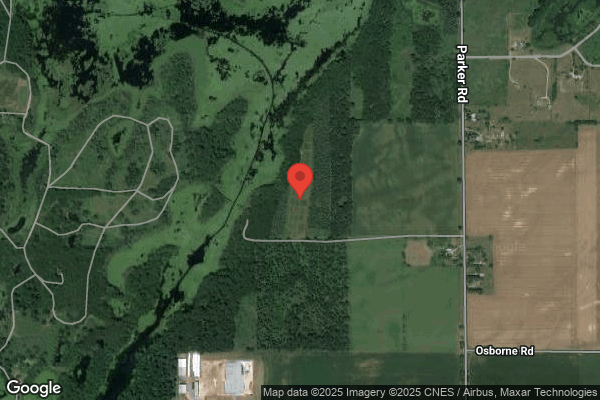

In [28]:
Image(data=image_bytes)


- roadmap
- satellite
- hybrid
- terrain

----

* 0–4 — Whole continents or regions (e.g., North America, Europe).
* 5–10 — Countries and large regions.
* 11–14 — Cities and metropolitan areas.
* 15–18 — Streets and neighborhoods.
* 19–21 (22) — Individual buildings and details (highest zoom).

```
  Complete workflow: enrich_biosample_with_map_interpretation() - fetches maps at multiple zoom levels and interprets them.

  AI agents:
  - geo_agent.py - geographic feature analysis
  - envo_agent.py - maps features to environmental ontology terms

  Usage example:
  from src.biosample_map_interpreter import interpret_map_with_cborg

```

In [29]:
with open('temp_map.png', 'wb') as f:
    f.write(image_bytes)

In [30]:
result = interpret_map_with_cborg('temp_map.png')


INFO:src.biosample_map_interpreter:Sending interpretation request to CBORG for image: temp_map.png
INFO:src.biosample_map_interpreter:Saved CBORG response to temp_map_response.json


In [31]:
result

{'full_response': {'id': 'chatcmpl-860569a85b124788a7a958794b1b13bf',
  'created': 1749586967,
  'model': 'lbl/qwen-vision',
  'object': 'chat.completion',
  'system_fingerprint': None,
  'choices': [{'finish_reason': 'stop',
    'index': 0,
    'message': {'content': 'The image depicts a rural area with a mix of natural and human-altered landscapes. \n\n1. **Natural features**: There are patches of dense green vegetation indicative of forested areas. The presence of lighter green areas suggests open fields or possibly agricultural land. No significant water bodies like lakes or rivers are immediately visible, but there may be smaller streams or wetlands within the forested regions. The terrain appears relatively flat, with no prominent mountainous features.\n\n2. **Human structures**: Roads are clearly visible, including Parker Rd and Osborne Rd, which intersect near the center of the image. These roads divide the landscape into sections, some of which appear to be farmland due to the

## Fetching OSM features and mapping to EnvO

In [32]:
# Get OSM features from your biosample coordinates
osm_features = query_osm_features(
  lat=random_biosample["asserted_lat"],
  lon=random_biosample["asserted_lon"],
  radius=1000  # meters, default is 1000
)

INFO:src.agent_test.osm_features:Querying OSM features at 42.476365, -85.451887 (attempt 1/3)
INFO:src.agent_test.osm_features:Found 2 relevant features


In [33]:
osm_features

[OSMFeature(feature_id='251415346', feature_type='natural:water', tags={'natural': 'water', 'water': 'pond'}, geometry_type='way', coordinates=(42.4782215, -85.4595369), area=None),
 OSMFeature(feature_id='3373705', feature_type='natural:water', tags={'name': 'Crooked Lake', 'natural': 'water', 'type': 'multipolygon', 'water': 'lake', 'wikidata': 'Q88273045'}, geometry_type='relation', coordinates=(42.4811929, -85.4442193), area=None)]

In [34]:
# Interpret your OSM features
mappings = interpret_osm_to_envo(osm_features, max_features=30)

INFO:src.notebook_osm_envo_agent:Processing 2 OSM features
INFO:httpx:HTTP Request: POST https://api.cborg.lbl.gov/chat/completions "HTTP/1.1 200 OK"
INFO:src.notebook_osm_envo_agent:✓ Mapped natural:water to ENVO:00000020
INFO:httpx:HTTP Request: POST https://api.cborg.lbl.gov/chat/completions "HTTP/1.1 200 OK"
INFO:src.notebook_osm_envo_agent:✓ Mapped natural:water to ENVO:00000020
INFO:src.notebook_osm_envo_agent:Progress: 2/2 features
INFO:src.notebook_osm_envo_agent:Successfully mapped 2/2 features


In [35]:
display_envo_mappings(mappings)

🌍 Found 2 EnvO mappings:

1. 🟢 lake (ENVO:00000020)
   Confidence: 0.85
   Reasoning: This OSM feature is tagged as natural water with the specific water type being 'pond'. In the EnvO ontology, ponds are typically classified under the broader category of lakes (ENVO:00000020), as both represent standing water bodies. While a pond is generally smaller than a lake, EnvO:00000020 encompasses various types of standing freshwater bodies including ponds. The feature has clear environmental and biological significance as aquatic habitats that support diverse ecosystems, provide wildlife habitat, and contribute to local hydrology. The mapping has high confidence because the feature type is unambiguous - it's clearly a natural water body, and lake is the most appropriate available EnvO term for standing water features.
------------------------------------------------------------
2. 🟢 lake (ENVO:00000020)
   Confidence: 0.95
   Reasoning: This is a clear and unambiguous mapping. The OSM feature